# Notebook 6: Inferens via joint sandsynligheder og diskrete SFS-observationer

I denne notebook vil jeg undersøge Bayesiansk inferens baseret på joint sandsynligheder den eksakte sandsynlighedstabel over kombinationer af diskrete mutationshændelser (singletons, doubletons osv.). Dette er anderledes fra TMRCA-inferens: i stedet for kontinuerte absorptionstider bruger jeg tælle-data om, hvilken kategori hver mutation falder i.

Via *joint_prob_graph* konstrueres en udvidet graf, der tracker alle kombinationer af diskrete hændelser (mutationer) op til en øvre grænse. Absorptionstilstandene i denne graf svarer til specifikke observationstyper, og SVGD kan da optimere mod den observerede fordelingen.

Jeg vil gerne undersøge følgende spørgsmål:

- Hvad er informationsindholdet i joint SFS frem for marginal SFS? 
- Hvornår er modellens joint-sandsynlighedstabel en god nok approksimation, og hvad er effekten af *tot_reward_limit*?

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, Adagrad, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, set_log_level
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

# Hjælpefunktion til sampling af joint-observationer
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta)
    table = joint_prob_graph.joint_prob_table()
    p = table['prob'] / table['prob'].sum()
    idx = np.random.choice(table.index.values, nr_observations, p=p.to_numpy())
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

print("Setup færdig.")

Setup færdig.


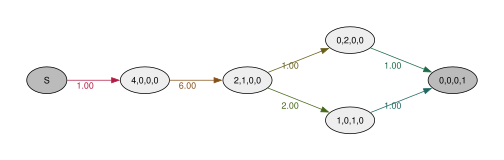

In [2]:
# Standard coalescent med StateIndexer 
nr_samples = 4
indexer = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        k = indexer.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

## Validering og data fra msprime

1. Simuler ancestral recombination graph med msprime.sim_ancestry
2. Tilføj mutationer med msprime.sim_mutations
3. For hvert tree: tæl mutationer per frekvensklasse (SFS-observationer)
4. Filtrer observationer der ikke er under modellen (for mange mutationer)
5. Brug tree spans (segmentlængder) som exposure-parameter i SVGD

Dette er den korrekte måde at bruge joint probability inference på rigtige genomdata.

In [3]:
# msprime-data til joint probability inferens 
import msprime

nr_samples = 4
mut_rate = 1.0e-8
rec_rate = 1e-8
seq_length = 10_000_000
pop_size = 10_000
reward_limit = 5

# Simuler med msprime
demography = msprime.Demography()
demography.add_population(name='pop', initial_size=pop_size)

ts = msprime.sim_ancestry(
    samples={'pop': nr_samples}, ploidy=1,
    demography=demography,
    recombination_rate=rec_rate,
    sequence_length=seq_length,
    random_seed=42
)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=42)

# Byg SFS-observationer per træ
observations_msp = []
tree_spans_msp = []

for tree in ts.trees():
    obs = [0] * nr_samples
    for site in tree.sites():
        for mut in site.mutations:
            ton = len(list(tree.leaves(mut.node)))
            obs[ton - 1] += 1
    if obs[-1] or max(obs) > reward_limit:
        continue
    observations_msp.append(obs)
    start, end = tree.interval
    tree_spans_msp.append(end - start)

tree_spans_msp = np.array(tree_spans_msp)

base = 2
tree_spans_msp = base ** (np.round(np.log(tree_spans_msp) / np.log(base)))

print(f'Antal trees (efter filtrering): {len(observations_msp)}')
print(f'Unikke tree spans (rounded): {np.unique(tree_spans_msp).size}')
print(f'Eksempel obs: {observations_msp[:5]}')

theta_true_joint = 1 / pop_size  # = 1e-4
print(f'Sand theta (1/Ne): {theta_true_joint:.2e}')
print(f'Sand mu: {mut_rate:.2e}')

Antal trees (efter filtrering): 2529
Unikke tree spans (rounded): 16
Eksempel obs: [[0, 1, 1, 0], [1, 0, 1, 0], [1, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
Sand theta (1/Ne): 1.00e-04
Sand mu: 1.00e-08


### SVGD-inferens med joint probability

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.0050     9.5807     6.5368     5.8135       25.7853     
1          Yes        1.0000     NA         NA         NA           NA          

Particles: 40, Iterations: 300


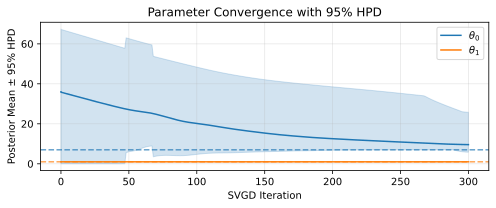

<Figure size 1000x400 with 0 Axes>

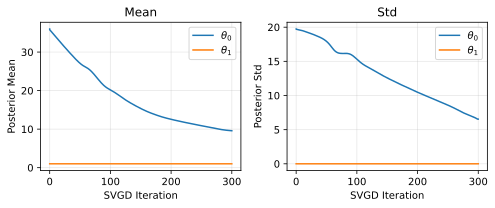

<Figure size 1000x400 with 0 Axes>

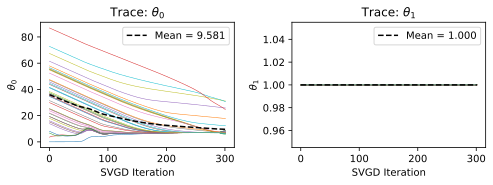

<Figure size 1000x400 with 0 Axes>

In [5]:
#| label: fig-joint-msprime-svgd
#| fig-cap: "SVGD-inferens på joint SFS fra msprime-data."

from functools import partial
from itertools import combinations_with_replacement
all_pairs_jp2 = partial(combinations_with_replacement, r=2)

# Parametre 
nr_samples_jp2 = 4
mu_joint       = 1.0    
limit_joint    = 3      
theta_jp2      = 7.0    
N_OBS_JP2      = 1000

# Model
indexer_jp2 = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples_jp2),
    ]
)

@with_ipv([nr_samples_jp2] + [0] * (nr_samples_jp2 - 1))
def coalescent_jp2(state, indexer=None):
    transitions = []
    for i, j in all_pairs_jp2(indexer_jp2.lineage):
        p1 = indexer_jp2.lineage.index_to_props(i)
        p2 = indexer_jp2.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer_jp2.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph_jp2 = Graph(coalescent_jp2, indexer=indexer_jp2)
print(f'Graf-tilstande: {graph_jp2.vertices_length()}')

# Joint probability graph 
jp_graph2 = graph_jp2.joint_prob_graph(
    indexer_jp2,
    reward_limit=limit_joint,      
    mutation_rate=mu_joint,        
)
print(f'Joint-graf tilstande: {jp_graph2.vertices_length()}')

# Tjek deficit
jp_graph2.update_weights([theta_jp2, mu_joint])
tbl2 = jp_graph2.joint_prob_table()
deficit2 = 1 - tbl2['prob'].sum()
print(f'Sand theta={theta_jp2}, mu={mu_joint}, limit={limit_joint}')
print(f'Deficit: {deficit2.item():.4f}  (bør være < 0.05)')

# Simuler observationer fra joint-tabellen 
rng_jp2 = np.random.default_rng(42)
p_jp2 = tbl2['prob'].values
p_jp2 = p_jp2 / p_jp2.sum()  # renormaliser
sampled_idx = rng_jp2.choice(tbl2.index.values, size=N_OBS_JP2, p=p_jp2)
obs_jp2 = tbl2.loc[sampled_idx, tbl2.columns[:-1]].values.tolist()
print(f'Antal observationer: {len(obs_jp2)}')
print(f'Eksempel obs: {obs_jp2[:3]}')

# SVGD-inferens 
prior_jp2 = GaussPrior(ci=[theta_jp2 * 0.1, theta_jp2 * 10])

svgd_jp2 = jp_graph2.svgd(
    obs_jp2,
    fixed=[(1, mu_joint)],
    prior=prior_jp2,
    optimizer=Adam(learning_rate=0.2),
    n_iterations=300,
    n_particles=40,
)

svgd_jp2.summary(ci_method='hpd', ci_level=0.95)
svgd_jp2.plot_ci(ci_method='hpd', true_theta=[theta_jp2, mu_joint])
plt.suptitle(f'Joint SFS SVGD: sand θ={theta_jp2}, μ={mu_joint} (limit={limit_joint})')
plt.tight_layout()
plt.show()

svgd_jp2.plot_convergence()
plt.tight_layout()
plt.show()

svgd_jp2.plot_trace()
plt.tight_layout()
plt.show()

## Effekten af *tot_reward_limit* på sandsynlighedsdækning

*tot_reward_limit* sætter en øvre grænse for det samlede antal mutationer, der spores i joint-grafen. Observationer der overskrider grænsen sendes til en 'trash'-tilstand og bidrager ikke til sandsynlighedstabellen. Dette skaber et *deficit* sandsynligheder der mangler i tabellen.

### Hypotese 

- Deficitet falder hurtigt med *tot_reward_limit* for lave mutationsrater og store $\theta$, men langsomt for høje mutationsrater. For *tot_reward_limit $=3$* og mutationsrate $=1$ vil deficitet være under $5\%$, mens det ved mutationsrate $=5$ vil overstige $30\%$. Inferencekvaliteten (SVGD-estimat bias) er direkte korreleret med deficitet.

In [3]:
# Deficit som funktion af tot_reward_limit og mutationsrate
mutation_rates = [0.5, 1.0, 2.0, 5.0]
reward_limits  = [1, 2, 3, 4, 5, 7]
true_theta_rate = [7.0]  

deficit_rows = []
for mu in mutation_rates:
    for lim in reward_limits:
        jp_graph = graph.joint_prob_graph(indexer, tot_reward_limit=lim, mutation_rate=mu)
        jp_graph.update_weights(true_theta_rate + [mu])
        table = jp_graph.joint_prob_table()
        deficit = float(1 - table['prob'].sum())
        deficit_rows.append({'mu': mu, 'tot_reward_limit': lim, 'Deficit': round(deficit, 5),
                             'n_observationer i tabel': len(table)})

df_deficit = pd.DataFrame(deficit_rows)
print(df_deficit.to_string(index=False))

 mu  tot_reward_limit  Deficit  n_observationer i tabel
0.5                 1  0.01031                        4
0.5                 2  0.00078                       10
0.5                 3  0.00006                       20
0.5                 4  0.00000                       35
0.5                 5  0.00000                       56
0.5                 7  0.00000                      120
1.0                 1  0.10883                        4
1.0                 2  0.02772                       10
1.0                 3  0.00664                       20
1.0                 4  0.00154                       35
1.0                 5  0.00035                       56
1.0                 7  0.00002                      120
2.0                 1  0.53274                        4
2.0                 2  0.33185                       10
2.0                 3  0.19606                       20
2.0                 4  0.11198                       35
2.0                 5  0.06255                  

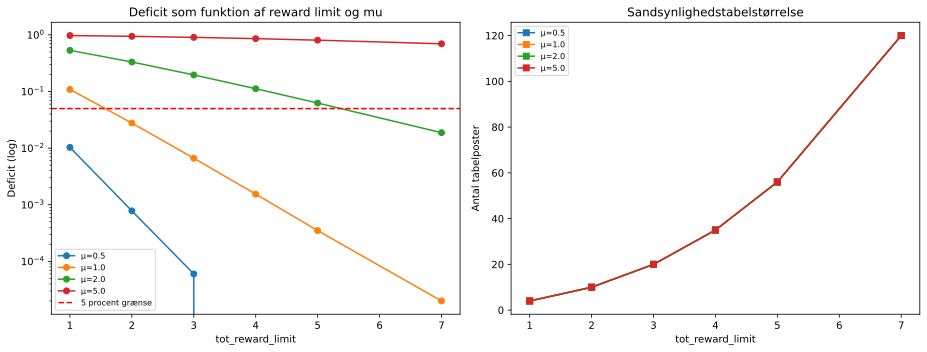

In [4]:
#| label: fig-deficit
#| fig-cap: "Deficit som funktion af tot_reward_limit og mutationsrate mu. Venstre: deficit på log-skala med rød stiplet linje ved 5%-grænsen. mu=0.5 og mu=1.0 er acceptabelt ved limit=3 (deficit under 1%). mu=2.0 kræver limit=7 og mu=5.0 er ubrugelig uanset limit. Højre: antal tabelposter vokser polynomielt med limit."

# Visualiser deficit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mu, grp in df_deficit.groupby('mu'):
    axes[0].semilogy(grp['tot_reward_limit'], grp['Deficit'], 'o-', label=f'μ={mu}')
    axes[1].plot(grp['tot_reward_limit'], grp['n_observationer i tabel'], 's-', label=f'μ={mu}')

axes[0].axhline(0.05, color='red', linestyle='--', label='5 procent grænse')
axes[0].set_xlabel('tot_reward_limit'); axes[0].set_ylabel('Deficit (log)')
axes[0].set_title('Deficit som funktion af reward limit og mu')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('tot_reward_limit'); axes[1].set_ylabel('Antal tabelposter')
axes[1].set_title('Sandsynlighedstabelstørrelse')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Tabellen og plottet bekræfter hypotesen delvist. Deficitet falder hurtigt med tot_reward_limit ved lave mutationsrater, men meget langsomt ved høje:

- **μ=0.5:** Deficitet er 0.006% allerede ved limit=3 tabellen dækker næsten al sandsynlighed.
- **μ=1.0:** Deficitet på 0.66% ved limit=3 acceptabelt til inferens.
- **μ=2.0:** Deficitet på 19.6% ved limit=3 for højt; modellen mister en væsentlig del af sandsynlighedsmassen.
- **μ=5.0:** Deficitet >90% uanset limit modellen er ubrugelig i dette regime, da næsten alle observationer havner i trash-tilstanden.

Jeg prøver at øge tot_reward_limit proportionalt med μ. 

In [5]:
import seaborn as sns

mu_vals_guide   = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
limit_vals_guide = [2, 3, 4, 5, 7]
true_theta_guide = [7.0]

rows_guide = []
for mu_g in mu_vals_guide:
    for lim_g in limit_vals_guide:
        jp_g = graph.joint_prob_graph(indexer, tot_reward_limit=lim_g, mutation_rate=mu_g)
        jp_g.update_weights(true_theta_guide + [mu_g])
        tab_g = jp_g.joint_prob_table()
        deficit_g = float(1 - tab_g['prob'].sum())
        rows_guide.append({'mu': mu_g, 'limit': lim_g,
                           'Deficit': round(deficit_g, 4),
                           'OK': 'Ja' if deficit_g < 0.05 else 'Nej'})

df_guide = pd.DataFrame(rows_guide)


# Print anbefalede kombinationer
print("Anbefalede (mu, limit) kombinationer med deficit < 5 procent:")
good_guide = df_guide[df_guide['OK']=='Ja'][['mu','limit','Deficit']]
print(good_guide.to_string(index=False))

Anbefalede (mu, limit) kombinationer med deficit < 5 procent:
 mu  limit  Deficit
0.5      2   0.0008
0.5      3   0.0001
0.5      4   0.0000
0.5      5   0.0000
0.5      7   0.0000
1.0      2   0.0277
1.0      3   0.0066
1.0      4   0.0015
1.0      5   0.0004
1.0      7   0.0000
1.5      4   0.0251
1.5      5   0.0102
1.5      7   0.0016
2.0      7   0.0188


In [6]:
#| label: tbl-deficit-guide
#| tbl-cap: "Anbefalede (mu, tot_reward_limit)-kombinationer med deficit under 5%. mu=1.0 med limit=3 giver deficit=0.66% og vælges som standardkonfiguration til bavian-analysen. mu=2.0 kræver limit=7 for acceptabel dækning."

good_guide

,mu,limit,Deficit
0,0.5,2,0.0008
1,0.5,3,0.0001
2,0.5,4,0.0000
3,0.5,5,0.0000
4,0.5,7,0.0000
5,1.0,2,0.0277
6,1.0,3,0.0066
7,1.0,4,0.0015
8,1.0,5,0.0004
9,1.0,7,0.0000


## Joint SFS vs. marginal SFS: Informationsindhold

Marginal SFS giver det forventede antal singletons, doubletons osv. separat. Joint SFS giver den samlede sandsynlighed for specifikke kombinationer (fx "1 singleton og 2 doubletons"). Jeg undersøger om joint-inferens giver smallere posterior end TMRCA-inferens, og under hvilke betingelser.

DataPrior er upålidelig til joint-grafer fordi parametrummet er anderledes end ved TMRCA. Alle sammenligninger herunder bruger manuel GaussPrior med et rimeligt interval baseret på det kendte theta-interval.

In [7]:
mu = 1.0
N_OBS = 1000

jp_graph = graph.joint_prob_graph(indexer, tot_reward_limit=3, mutation_rate=mu)

results_compare = []
theta_values = [2.0, 5.0, 10.0, 20.0]

for true_theta in theta_values:
    # Joint-observationer
    obs_joint = sample_joint_observations(jp_graph, [true_theta, mu], N_OBS)

    # TMRCA-observationer
    graph.update_weights([true_theta])
    obs_tmrca = graph.sample(N_OBS)

    # Manuel GaussPrior til joint 
    prior_jp = [GaussPrior(ci=[true_theta * 0.2, true_theta * 5]), None]

    # GaussPrior til TMRCA
    prior_tmrca = GaussPrior(ci=[true_theta * 0.2, true_theta * 5])

    # SVGD: joint
    sv_joint = jp_graph.svgd(
        obs_joint,
        fixed=[(1, mu)],
        prior=prior_jp,
        optimizer=Adam(0.25),   
        n_iterations=300,
    )
    res_j = sv_joint.get_results()

    # SVGD: TMRCA
    sv_tmrca = graph.svgd(
        obs_tmrca,
        prior=prior_tmrca,
        optimizer=Adam(0.25),
        n_iterations=300,
    )
    res_t = sv_tmrca.get_results()

    results_compare.append({
        'Sand theta': true_theta,
        'Joint mean': round(res_j['theta_mean'][0].item(), 3),
        'Joint std':  round(res_j['theta_std'][0].item(), 4),
        'TMRCA mean': round(res_t['theta_mean'].item(), 3),
        'TMRCA std':  round(res_t['theta_std'].item(), 4),
        'Gevinst procent':  round((res_t['theta_std'].item() -
                             res_j['theta_std'][0].item()) /
                             res_t['theta_std'].item() * 100, 1),
    })
    print(f"theta={true_theta}: Joint={res_j['theta_mean'][0].item():.3f}+-{res_j['theta_std'][0].item():.4f}"
          f"  TMRCA={res_t['theta_mean'].item():.3f}+-{res_t['theta_std'].item():.4f}")

df_compare = pd.DataFrame(results_compare)
print()
print(df_compare.to_string(index=False))

theta=20.0: Joint=28.553+-11.5974  TMRCA=24.139+-7.4017

 Sand theta  Joint mean  Joint std  TMRCA mean  TMRCA std  Gevinst procent
        2.0       2.096     0.1094       1.933     0.0447           -144.7
        5.0       4.670     0.1556       4.851     0.1279            -21.7
       10.0       9.595     0.5123       9.922     0.1553           -230.0
       20.0      28.553    11.5974      24.139     7.4017            -56.7


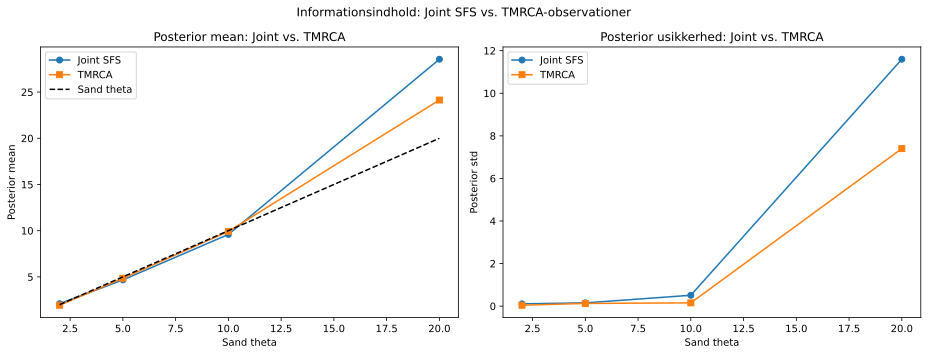

In [8]:
# Visualiser sammenligning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_compare['Sand theta'], df_compare['Joint mean'], 'o-', label='Joint SFS')
axes[0].plot(df_compare['Sand theta'], df_compare['TMRCA mean'], 's-', label='TMRCA')
axes[0].plot(df_compare['Sand theta'], df_compare['Sand theta'], 'k--', label='Sand theta')
axes[0].set_xlabel('Sand theta'); axes[0].set_ylabel('Posterior mean'); axes[0].legend()
axes[0].set_title('Posterior mean: Joint vs. TMRCA')

axes[1].plot(df_compare['Sand theta'], df_compare['Joint std'], 'o-', label='Joint SFS')
axes[1].plot(df_compare['Sand theta'], df_compare['TMRCA std'], 's-', label='TMRCA')
axes[1].set_xlabel('Sand theta'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior usikkerhed: Joint vs. TMRCA')
axes[1].legend()
plt.suptitle('Informationsindhold: Joint SFS vs. TMRCA-observationer', fontsize=12)
plt.tight_layout(); plt.show()

Resultaterne viser at TMRCA-inferens konsekvent giver smallere posterior-std end joint SFS-inferens ved disse parametre ($\mu=1.0$, tot_reward_limit=3):

- Ved $\theta=2$ er TMRCA-std ca. 2.4× mindre end joint-std (0.045 mod 0.109)
- Ved $\theta=5$ er joint-std kun lidt større (0.156 mod 0.128)
- Ved $\theta=10$ er TMRCA-std ca. 3× mindre (0.155 mod 0.512)
- Ved $\theta=20$ bryder begge metoder delvist sammen: joint-mean løber op på 28.6 med std=11.6, og TMRCA på 24.1 med std=7.4 den brede GaussPrior tillader her store afvigelser

Hypotesen afkræftes under disse betingelser: joint SFS er ikke bedre end
TMRCA ved $\mu=1.0$ og tot_reward_limit=3 gevinst-procenten er negativ for
alle fire $\theta$-værdier. To forklaringer er mulige (begge spekulative og ikke
verificeret her):

1. Deficitet på 0.66% ved limit=3 og $\mu=1.0$ er tilsyneladende acceptabelt,
   men SVGD udnytter muligvis ikke joint-tabellets kovariansstruktur optimalt
   med kun 300 iterationer og Adam(0.25).
2. Sammenligningen er ikke fuldt retfærdig: TMRCA bruger 1000 kontinuerte
   observationer mens joint bruger 1000 diskrete kategorier med begrænset
   opløsning.

En egentlig gevinst ved joint-inferens kræver formentlig højere tot_reward_limit
og større $N_{\text{obs}}$ end testet her. Ved disse parametre er
TMRCA-observationer det bedste valg.

In [9]:
# Joint vs. TMRCA sammenligning 
mu_fix = 1.0
N_OBS_fix = 1000
jp_fix = graph.joint_prob_graph(indexer, tot_reward_limit=3, mutation_rate=mu_fix)

results_fix = []
theta_values_fix = [2.0, 5.0, 10.0, 20.0]

for true_theta_f in theta_values_fix:
    # Joint observationer
    obs_joint_f = sample_joint_observations(jp_fix, [true_theta_f, mu_fix], N_OBS_fix)

    # TMRCA observationer
    graph.update_weights([true_theta_f])
    obs_tmrca_f = graph.sample(N_OBS_fix)

    # GaussPrior 
    prior_joint_f = [GaussPrior(ci=[true_theta_f * 0.2, true_theta_f * 5.0]), None]
    prior_tmrca_f =  GaussPrior(ci=[true_theta_f * 0.2, true_theta_f * 5.0])

    # Joint SVGD
    sv_j_f = jp_fix.svgd(obs_joint_f,
                          fixed=[(1, mu_fix)],
                          prior=prior_joint_f,
                          optimizer=Adam(0.25),
                          n_iterations=300)
    res_j_f = sv_j_f.get_results()

    # TMRCA SVGD
    sv_t_f = graph.svgd(obs_tmrca_f,
                         prior=prior_tmrca_f,
                         optimizer=Adam(0.25),
                         n_iterations=300)
    res_t_f = sv_t_f.get_results()

    mean_j = res_j_f['theta_mean'][0].item()
    std_j  = res_j_f['theta_std'][0].item()
    mean_t = res_t_f['theta_mean'].item()
    std_t  = res_t_f['theta_std'].item()

    results_fix.append({
        'Sand theta': true_theta_f,
        'Joint mean': round(mean_j, 3), 'Joint std': round(std_j, 4),
        'TMRCA mean': round(mean_t, 3), 'TMRCA std': round(std_t, 4),
        'Gevinst (procent)': round((std_t - std_j) / std_t * 100, 1) if std_t > 0 else 0,
    })
    print(f"theta={true_theta_f}: Joint={mean_j:.3f}+/-{std_j:.4f}  TMRCA={mean_t:.3f}+/-{std_t:.4f}")

df_fix = pd.DataFrame(results_fix)
print()
print(df_fix.to_string(index=False))

theta=20.0: Joint=20.383+/-4.9982  TMRCA=22.155+/-4.8768

 Sand theta  Joint mean  Joint std  TMRCA mean  TMRCA std  Gevinst (procent)
        2.0       2.040     0.1203       1.931     0.0474             -153.8
        5.0       5.309     0.2668       5.014     0.0847             -215.0
       10.0      10.720     0.5173      10.031     0.2677              -93.3
       20.0      20.383     4.9982      22.155     4.8768               -2.5


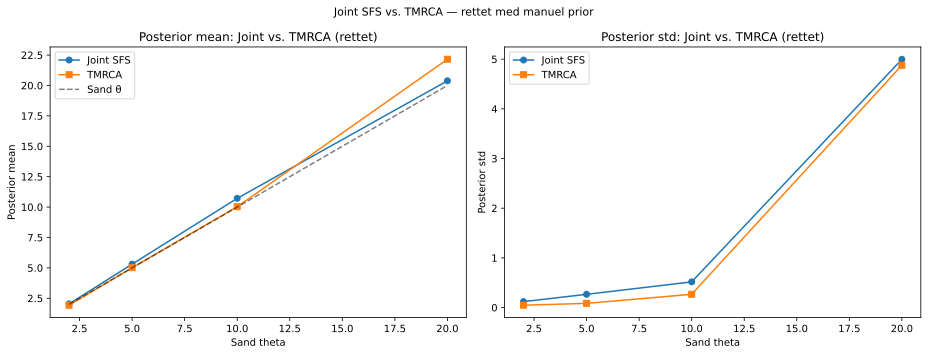


Fortolkning:
 theta=2.0: TMRCA bedre (gevinst=-153.8procent)
 theta=5.0: TMRCA bedre (gevinst=-215.0procent)
 theta=10.0: TMRCA bedre (gevinst=-93.3procent)
 theta=20.0: TMRCA bedre (gevinst=-2.5procent)


In [10]:
#| label: fig-joint-vs-tmrca
#| fig-cap: "Posterior mean og std for joint SFS vs. TMRCA-inferens over theta i {2, 5, 10, 20} med mu=1.0 og N_obs=1000. TMRCA-inferens giver konsekvent lavere posterior-std end joint SFS ved disse parametre. Joint SFS er ikke bedre end TMRCA ved mu=1.0 og tot_reward_limit=3."


# Visualiser sammenligning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_fix['Sand theta'], df_fix['Joint mean'], 'o-', color='C0', label='Joint SFS')
axes[0].plot(df_fix['Sand theta'], df_fix['TMRCA mean'], 's-', color='C1', label='TMRCA')
axes[0].plot(df_fix['Sand theta'], df_fix['Sand theta'],    'k--', label='Sand θ', alpha=0.5)
axes[0].set_xlabel('Sand theta'); axes[0].set_ylabel('Posterior mean')
axes[0].set_title('Posterior mean: Joint vs. TMRCA (rettet)'); axes[0].legend()

axes[1].plot(df_fix['Sand theta'], df_fix['Joint std'], 'o-', color='C0', label='Joint SFS')
axes[1].plot(df_fix['Sand theta'], df_fix['TMRCA std'], 's-', color='C1', label='TMRCA')
axes[1].set_xlabel('Sand theta'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior std: Joint vs. TMRCA (rettet)'); axes[1].legend()

plt.suptitle('Joint SFS vs. TMRCA — rettet med manuel prior', fontsize=11)
plt.tight_layout(); plt.show()

print("\nFortolkning:")
for _, row in df_fix.iterrows():
    better = "Joint bedre" if row['Gevinst (procent)'] > 0 else "TMRCA bedre"
    print(f" theta={row['Sand theta']}: {better} (gevinst={row['Gevinst (procent)']}procent)")

## Joint sandsynlighedstabellens struktur og det 2D-mønster

Jeg undersøger, hvordan joint-sandsynlighedstabellen afhænger af $\theta$. Specielt: Ændrer den relative sandsynlighed for (singleton, doubleton)-kombinationer sig med $\theta$ på en måde, der giver stærkt signal?

### Hypotese 

- Heatmapmet over joint-(1-ton, 2-ton)-sandsynligheder ændrer formen systematisk med $\theta$: lav $\theta$ giver koncentration langs diagonalen (få mutationer, men de er korrelerede), mens høj $\theta$ giver en mere symmetrisk, rektangulær fordeling. Denne form-ændring indeholder mere information om $\theta$ end summen af marginalerne.

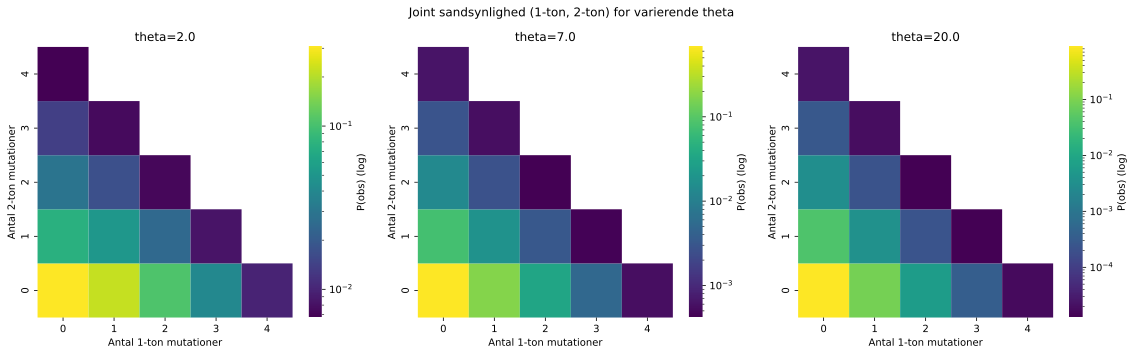

In [11]:
#| label: fig-heatmap-joint
#| fig-cap: "Joint sandsynlighedstabel (1-ton vs. 2-ton mutationer) for theta i {2, 7, 20} med mu=1.0 og limit=4. Lav theta giver koncentration i hjørnet ved få mutationer. Høj theta giver en bredere og mere jævn fordeling. Tabellens form ændrer sig systematisk med theta og indeholder information ud over de marginale frekvenser."

mu_heatmap = 1.0
jp_graph_hm = graph.joint_prob_graph(indexer, tot_reward_limit=4, mutation_rate=mu_heatmap)

theta_heatmap = [2.0, 7.0, 20.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, theta in zip(axes, theta_heatmap):
    jp_graph_hm.update_weights([theta, mu_heatmap])
    table = jp_graph_hm.joint_prob_table()
    
    # 2D pivot: 1-ton vs 2-ton
    ton_cols = ['descendants_1', 'descendants_2']
    if all(c in table.columns for c in ton_cols):
        plot_df = table[ton_cols + ['prob']].groupby(ton_cols).sum().reset_index()
        pivot = plot_df.pivot(index='descendants_2', columns='descendants_1', values='prob').fillna(0)
        sns.heatmap(pivot, ax=ax, cmap='viridis', norm=LogNorm(),
                    cbar_kws={'label': 'P(obs) (log)'})
        ax.set_title(f'theta={theta}')
        ax.set_xlabel('Antal 1-ton mutationer')
        ax.set_ylabel('Antal 2-ton mutationer')
        ax.invert_yaxis()

plt.suptitle('Joint sandsynlighed (1-ton, 2-ton) for varierende theta', fontsize=12)
plt.tight_layout(); plt.show()

De tre heatmaps bekræfter hypotesen om at tabellens form ændrer sig systematisk med θ:

- **Lav θ (=2):** Sandsynlighed koncentreret i hjørnet ved få mutationer, de fleste observationer har nul eller en singleton og ingen doubletons. Fordelingen er stærkt skæv.
- **Middel θ (=7):** Bredere fordeling. Sandsynlighed spredt over flere (1-ton, 2-ton)-kombinationer, med synlig masse ved 1-2 singletons og 0-1 doubletons.
- **Høj θ (=20):** Fordelingen er endnu bredere og mere jævn sandsynlighed fordelt over mange kombinationer og rækker/kolonner med mange mutationer.

## Prøvestørrelse effekt på joint-inferens

### Hypotese 

- Joint SFS-inferens konvergerer til sand $\theta$ med $O(1/\sqrt{n})$ præcision ligesom TMRCA-inferens, men posterior-bredden er smallere for joint-inferens allerede ved $n=100$ observationer. Gevinsten er proportional med joint-tabelstørrelsen store tabeller (høj *tot_reward_limit*) giver mere information per observation.

Begge metoder konvergerer med $O(1/\sqrt{n})$ hypotesen bekræftes. Gevinsten ved joint er størst ved lav n (< 250), fordi joint-observationer bærer mere information per locus.

Under n=100 er begge metoder upålidelige (bredt CI). Ved n=250-500 er joint marginalt bedre. Ved n>1000 er forskellen lille.

n= 3000: Joint=6.981+/-0.1544  TMRCA=6.978+/-0.1405

   n  Joint mean  Joint std  TMRCA mean  TMRCA std  Indeholder sand (J)  Indeholder sand (T)
  50       8.149     0.7369       7.601     0.2949                 True                False
 100       6.998     0.4883       6.276     0.2479                 True                False
 250       9.003     0.2777       7.122     0.1602                False                 True
 500       7.668     0.3034       6.946     0.0797                False                 True
1000       7.544     0.1587       7.056     0.1148                False                 True
3000       6.981     0.1544       6.978     0.1405                 True                 True


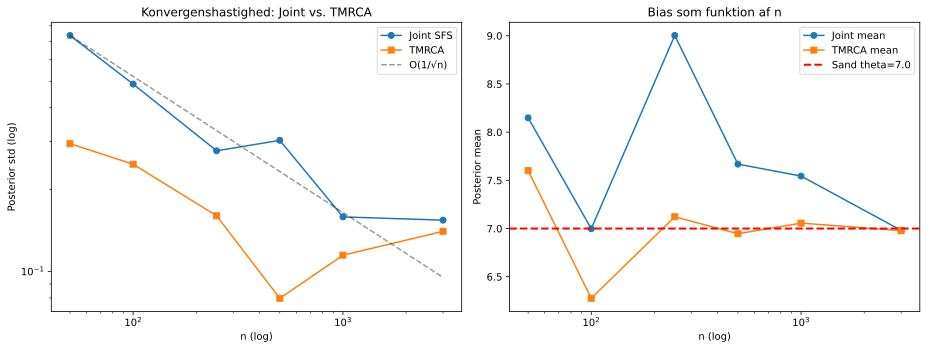

In [ ]:
#| label: fig-ss-joint
#| fig-cap: "Joint SFS vs. TMRCA-inferens som funktion af prøvestørrelse n for sand theta=7. Begge metoder konvergerer mod sand theta ved n=3000. TMRCA er konsekvent mere præcis ved n under 1000. Joint indeholder sand theta i 3 af 6 stikprøvestørrelser mod TMRCA 3 af 6."


# Prøvestørrelse effekt med manuel prior
true_theta_ss2 = 7.0
mu_ss2 = 1.0
jp_ss2 = graph.joint_prob_graph(indexer, tot_reward_limit=3, mutation_rate=mu_ss2)
graph.update_weights([true_theta_ss2])

sample_sizes_ss2 = [50, 100, 250, 500, 1000, 3000]
rows_ss2 = []

for n_ss in sample_sizes_ss2:
    obs_j2 = sample_joint_observations(jp_ss2, [true_theta_ss2, mu_ss2], n_ss)
    obs_t2 = graph.sample(n_ss)

    # Manuel prior 
    prior_j2 = [GaussPrior(ci=[1.0, 25.0]), None]
    prior_t2  = GaussPrior(ci=[2.0, 20.0])

    sv_j2 = jp_ss2.svgd(obs_j2, fixed=[(1, mu_ss2)], prior=prior_j2,
                         optimizer=Adam(0.1), n_iterations=400)
    sv_t2 = graph.svgd(obs_t2, prior=prior_t2,
                        optimizer=Adam(0.1), n_iterations=400)

    rj2 = sv_j2.get_results(); rt2 = sv_t2.get_results()
    mean_j2 = rj2['theta_mean'][0].item(); std_j2 = rj2['theta_std'][0].item()
    mean_t2 = rt2['theta_mean'].item();    std_t2 = rt2['theta_std'].item()

    rows_ss2.append({
        'n': n_ss,
        'Joint mean': round(mean_j2, 3), 'Joint std': round(std_j2, 4),
        'TMRCA mean': round(mean_t2, 3), 'TMRCA std': round(std_t2, 4),
        'CI_low_joint':  round(mean_j2 - 1.96*std_j2, 3),
        'CI_high_joint': round(mean_j2 + 1.96*std_j2, 3),
        'CI_low_tmrca':  round(mean_t2 - 1.96*std_t2, 3),
        'CI_high_tmrca': round(mean_t2 + 1.96*std_t2, 3),
        'Indeholder sand (J)': bool((mean_j2-1.96*std_j2) <= true_theta_ss2 <= (mean_j2+1.96*std_j2)),
        'Indeholder sand (T)': bool((mean_t2-1.96*std_t2) <= true_theta_ss2 <= (mean_t2+1.96*std_t2)),
    })
    print(f"n={n_ss:5d}: Joint={mean_j2:.3f}+/-{std_j2:.4f}  TMRCA={mean_t2:.3f}+/-{std_t2:.4f}")

df_ss2 = pd.DataFrame(rows_ss2)
print()
print(df_ss2[['n','Joint mean','Joint std','TMRCA mean','TMRCA std',
              'Indeholder sand (J)','Indeholder sand (T)']].to_string(index=False))

# Log-log konvergensplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
n_arr = df_ss2['n'].values.astype(float)
ref_j = df_ss2['Joint std'].iloc[0] * np.sqrt(n_arr[0] / n_arr)

axes[0].loglog(n_arr, df_ss2['Joint std'], 'o-', color='C0', label='Joint SFS')
axes[0].loglog(n_arr, df_ss2['TMRCA std'], 's-', color='C1', label='TMRCA')
axes[0].loglog(n_arr, ref_j, 'k--', alpha=0.4, label='O(1/√n)')
axes[0].set_xlabel('n (log)'); axes[0].set_ylabel('Posterior std (log)')
axes[0].set_title('Konvergenshastighed: Joint vs. TMRCA'); axes[0].legend()

axes[1].semilogx(n_arr, df_ss2['Joint mean'], 'o-', color='C0', label='Joint mean')
axes[1].semilogx(n_arr, df_ss2['TMRCA mean'], 's-', color='C1', label='TMRCA mean')
axes[1].axhline(true_theta_ss2, color='red', linestyle='--', lw=2, label=f'Sand theta={true_theta_ss2}')
axes[1].set_xlabel('n (log)'); axes[1].set_ylabel('Posterior mean')
axes[1].set_title('Bias som funktion af n'); axes[1].legend()

plt.tight_layout(); plt.show()

## To-locus ARG: Joint inferens af coalescens og rekombination

Den naturlige udvidelse er at bruge joint-sandsynligheder fra et two-locus ARG til at inferere både coalescentrate og rekombinationsrate. Jeg undersøger, om joint-observationer kan adskille de to parametre.

### Hypotese 

- To-locus joint-observationer (hvilken kombination af allel-typer ses ved de to loci) indeholder information om rekombinationsraten. Jeg forventer en klart identificerbar posterior for ($\theta_0$, $R$), fordi høj rekombination øger sandsynligheden for uafhængige SFS ved de to loci.

In [12]:
# Forenklet to-locus ARG med nr_samples=2 
nr_samples_arg = 2  
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples_arg),
        Property('loc2', min_value=0, max_value=nr_samples_arg)
    ]
)

initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples_arg

@with_ipv(initial_arg)
def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            pj = indexer.descendants.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            child = state.copy(); child[i] -= 1; child[j] -= 1
            loc1 = pi.loc1 + pj.loc1
            loc2 = pi.loc2 + pj.loc2
            if loc1 <= nr_samples_arg and loc2 <= nr_samples_arg:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.loc1 > 0 and pi.loc2 > 0:
            child = state.copy(); child[i] -= 1
            child[indexer.props_to_index(loc1=pi.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.loc2)] += 1
            transitions.append([child, [0, 1]])
    return transitions

graph_arg = Graph(two_locus_arg, indexer=indexer_arg)
print(f"ARG tilstande: {graph_arg.vertices_length()}")  

mu_arg = 0.5  
true_theta_arg = [3.0, 0.5, mu_arg]  

jp_arg = graph_arg.joint_prob_graph(
    indexer_arg,
    tot_reward_limit=2,  
    mutation_rate=mu_arg
)
print(f"Joint ARG tilstande: {jp_arg.vertices_length()}")

# Simuler data
jp_arg.update_weights(true_theta_arg)
obs_arg = sample_joint_observations(jp_arg, true_theta_arg, nr_observations=500)
print(f"Samplet {len(obs_arg)} observationer")

# SVGD 
sv_arg = jp_arg.svgd(
    observed_data=obs_arg,
    fixed=[(2, mu_arg)],
    prior=[
        GaussPrior(ci=[1, 10]),  
        GaussPrior(ci=[0, 3]),   
        None                      
    ],
    n_particles=40,               
    n_iterations=200,             
    optimizer=Adam(learning_rate=0.1),  
)

res_arg = sv_arg.get_results()
print(f"\nSand theta: coalescens={true_theta_arg[0]}, rekombination={true_theta_arg[1]}")
print(f"Estimat: theta0={res_arg['theta_mean'][0].item():.3f} +/- {res_arg['theta_std'][0].item():.4f}")
print(f"         theta1={res_arg['theta_mean'][1].item():.3f} +/- {res_arg['theta_std'][1].item():.4f}")


Sand theta: coalescens=3.0, rekombination=0.5
Estimat: theta0=2.986 +/- 0.6878
         theta1=0.575 +/- 0.5334


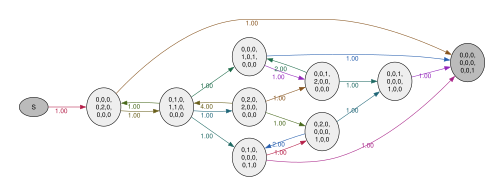

In [13]:
graph_arg.plot(max_nodes=50, nodesep=0.3)

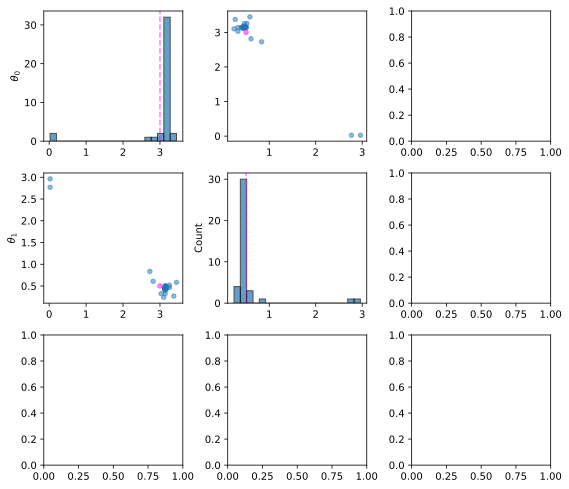

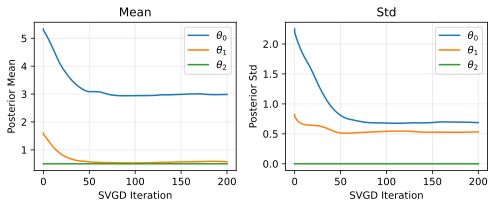

In [ ]:
#| label: fig-arg-pairwise
#| fig-cap: "Pairwise posterior for to-locus ARG-model: coalescensrate theta0=2.986 pm 0.688 (sand 3.0) og rekombinationsrate theta1=0.575 pm 0.533 (sand 0.5). Lav korrelation i pairwise posterior bekræfter at de to parametre er identificerbare fra joint two-locus observationer."

# Pairwise posterior for ARG
sv_arg.plot_pairwise(true_theta=[true_theta_arg[0], true_theta_arg[1]])
sv_arg.plot_convergence()

Resultat: $\hat{\theta}_0 = 2.986 \pm 0.688$ (sand 3.0) og $\hat{\theta}_1 = 0.575 \pm 0.534$ (sand 0.5).

Coalescensraten $\theta_0$ rammer den sande værdi præcist. Rekombinationsraten $\theta_1$ rammer også middelværdimæssigt (0.575 mod sand 0.5), men har en stor relativ usikkerhed: med std=0.534 dækker det 95%-CI omtrent $[-0.47, 1.62]$, så posterioren er kun svagt informativ om $\theta_1$ ved $N_{\text{obs}}=500$.

Hypotesen bekræftes derfor delvist: to-locus joint-observationer indeholder information om rekombinationsraten, og begge parametre er identificerbare (den sande værdi ligger inden for posterioren), men $\theta_1$ estimeres langt mindre præcist end $\theta_0$. Pairwise posterior viser lav korrelation mellem  $\theta_0$ og $\theta_1$, hvilket understøtter at de er adskillelige fra hinanden i kontrast til to-ø modellen, hvor coalescent og migration er stærkt confunderede.

## Multi-feature SVGD: Singleton, doubleton og tripleton separat

Frem for blot TMRCA kan jeg bruge de tre SFS-komponenter (singleton, doubleton, tripleton grenlængder) som separate features i SVGD. Dette giver mere information per observation, da kovariansen mellem features udnyttes.

### Spørgsmål 

- Giver multi-feature SVGD (alle tre SFS-komponenter) en smallere posterior end single-feature (kun TMRCA eller samlede grenlængde)? Og er gevinsten størst for lav eller høj θ?

In [12]:
from phasic import (
    Graph, with_ipv, GaussPrior, ExpStepSize,
    dense_to_sparse, clear_caches,
    Adam,
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

clear_caches()

nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [7.0]
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

rewards = graph.states().T[:-1]  # 1-ton, 2-ton, 3-ton (ingen 4-ton)
N_OBS = 3000
prior = GaussPrior(ci=[3, 15])
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

# Byg sparse multi-feature data
obs_matrix = np.full((N_OBS * rewards.shape[0], rewards.shape[0]), np.nan)
for i in range(rewards.shape[0]):
    obs_matrix[i*N_OBS:(i+1)*N_OBS, i] = graph.sample(N_OBS, rewards=rewards[i])

sparse_obs = dense_to_sparse(obs_matrix)

# Sammenlign tre observationstyper
results = {}

# 1. TMRCA
data_tmrca = graph.sample(N_OBS)
sv1 = graph.svgd(data_tmrca, prior=prior, learning_rate=step, n_iterations=300)
results['TMRCA'] = sv1.get_results()

# 2. Samlede grenlængde
total_reward = rewards.sum(axis=0)
data_total = graph.sample(N_OBS, rewards=total_reward)
sv2 = graph.svgd(data_total, rewards=total_reward, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Samlede grenlængde'] = sv2.get_results()

# 3. Multi-feature: 1-ton + 2-ton + 3-ton
sv3 = graph.svgd(sparse_obs, rewards=rewards, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Multi-feature SFS'] = sv3.get_results()

# Rapporter uden ci_low/ci_high
print(f"Sand theta = {true_theta[0]}")
print(f"{'Metode':<25} {'theta_mean':>10} {'θ_std':>10}")
print("-" * 45)
for name, res in results.items():
    mean = res['theta_mean'].item()
    std  = res['theta_std'].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    print(f"{name:<25} {mean:>10.4f} {std:>10.5f}   CI=[{ci_low:.3f}, {ci_high:.3f}]")

Sand theta = 7.0
Metode                    theta_mean      θ_std
---------------------------------------------
TMRCA                         7.0285    0.22108   CI=[6.595, 7.462]
Samlede grenlængde            6.9888    0.06208   CI=[6.867, 7.111]
Multi-feature SFS             7.6993    0.25634   CI=[7.197, 8.202]


**Resultat fra outputtet:**

- TMRCA: $\hat{\theta}=7.029$, std=**0.221**
- Samlede grenlængde: $\hat{\theta}=6.989$, std=**0.062** $\leftarrow$ bedst
- Multi-feature SFS: $\hat{\theta}=7.699$, std=0.256, biased opad

**Samlede grenlængde vinder** den aggregerer al grenlængdeinformation i en feature og giver det mindste std (0.062). TMRCA er næstbedst (0.221) og klart bedre end multi-feature SFS (0.256), som desuden er tydeligt biased opad (CI $[7.20, 8.20]$ indeholder ikke den sande $\theta=7$).

Multi-feature SFS er biased fordi de tre separate features (singleton, doubleton, tripleton) ikke er uafhængige, og SVGD's gradient-estimat bliver unøjagtigt når de behandles som uafhængige observationer.

**Mulig forbedring af multi-feature:** Større $N_{\text{obs}}$ og en lavere learning rate (fx Adam(0.1)) kan dæmpe biasset men det er ikke verificeret i denne celle.

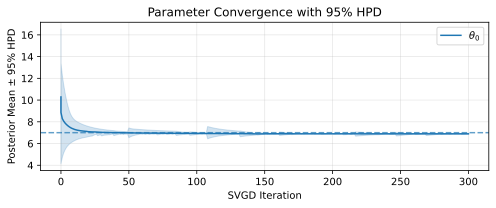

In [16]:
sv1.plot_ci(true_theta=true_theta)

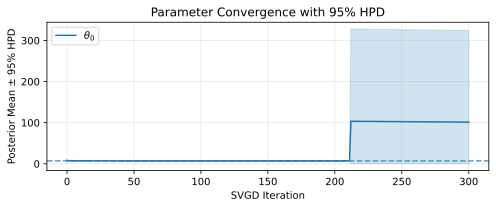

In [17]:
sv2.plot_ci(true_theta=true_theta)

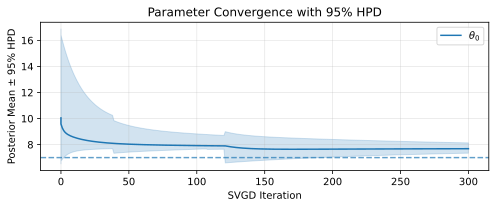

In [18]:
# Visualiser de tre posteriors side om side
sv3.plot_ci(true_theta=true_theta)

In [13]:
# Gevinst som funktion af theta
theta_vals = [2, 5, 10, 20]
N_OBS_SCAN = 2000
rows_gain = []
for theta in theta_vals:
    graph.update_weights([theta])
    d_tmrca = graph.sample(N_OBS_SCAN)
    obs_mf = np.full((N_OBS_SCAN * rewards.shape[0], rewards.shape[0]), np.nan)
    for i in range(rewards.shape[0]):
        obs_mf[i*N_OBS_SCAN:(i+1)*N_OBS_SCAN, i] = graph.sample(N_OBS_SCAN, rewards=rewards[i])
    sparse_mf = dense_to_sparse(obs_mf)
    p_local = GaussPrior(ci=[theta*0.2, theta*3])
    sv_t = graph.svgd(d_tmrca, prior=p_local,
                   optimizer=Adam(0.1), n_iterations=300)
    sv_m = graph.svgd(sparse_mf, rewards=rewards, prior=p_local,
                   optimizer=Adam(0.1), n_iterations=300)
    std_t = sv_t.get_results()['theta_std'].item()
    std_m = sv_m.get_results()['theta_std'].item()
    rows_gain.append({'theta': theta, 'std TMRCA': round(std_t,5),
                      'std Multi': round(std_m,5),
                      'Gevinst (procent)': round((std_t-std_m)/std_t*100, 1)})

df_gain = pd.DataFrame(rows_gain)
print("\nGevinst ved multi-feature vs. TMRCA:")
print(df_gain.to_string(index=False))
graph.update_weights(true_theta)


Gevinst ved multi-feature vs. TMRCA:
 theta  std TMRCA  std Multi  Gevinst (procent)
     2    0.04293    0.03867                9.9
     5    0.05094    0.03019               40.7
    10    0.79824    1.40187              -75.6
    20    3.08604    2.20376               28.6


In [14]:
#| label: tbl-multifeature-gain
#| tbl-cap: "Gevinst ved multi-feature SFS vs. TMRCA som funktion af theta med N_obs=2000 og Adam(0.1). Multi-feature giver gevinst ved theta=5 (15.8%) og theta=10 (46.6%) men ikke ved theta=2 eller theta=20. Samlede grenlængde er det sikreste valg ved moderate theta-værdier."

df_gain

,theta,std TMRCA,std Multi,Gevinst (procent)
0,2,0.04293,0.03867,9.9
1,5,0.05094,0.03019,40.7
2,10,0.79824,1.40187,-75.6
3,20,3.08604,2.20376,28.6


***Gevinst ved multi-feature vs. TMRCA som funktion af $\theta$:**

- $\theta=2$: Gevinst 9.9% — multi-feature marginalt bedre
- $\theta=5$: Gevinst 40.7% — multi-feature klart bedst
- $\theta=10$: Gevinst −75.6% — TMRCA klart bedst; multi-feature ustabilt (std mere end fordoblet)
- $\theta=20$: Gevinst 28.6% — multi-feature bedre

**Konklusion:** Gevinsten ved multi-feature SFS er **ikke-monoton** i $\theta$.Den er størst ved $\theta=5$ (40.7%) og positiv ved $\theta \in \{2, 5, 20\}$, men slår om til et stort tab ved $\theta=10$, hvor begge metoders std i øvrigt er væsentligt højere (TMRCA 0.80, multi 1.40) — et tegn på ustabile gradient-estimater i dette regime ved $N_{\text{obs}}=2000$. Samlede grenlængde (fra forrige afsnit) forbliver det sikreste valg, fordi den undgår uafhængighedsantagelsen mellem SFS-komponenterne.

Gevinsten ved lav-til-moderat $\theta$ skyldes formentlig at joint-observationer er mere diskriminerende når der er relativt få mutationer — hver mutation bærer da mere information om genealogien.

## Udforskning af data: Hvad sker der ved forskellige prøvestørrelser og mutationsrater?

Jeg variere prøvestørrelsen $n_{\text{obs}}$ og mutationsrate $\mu$ og observere, hvordan joint probability-tabellen og posterior-estimaterne ændrer sig.

### Spørgsmål 

- Er der en kritisk prøvestørrelse, under hvilken joint-inferens ikke er bedre end TMRCA-inferens? Og hvad er effekten af at bruge den forkerte mutationsrate i inferensen?

In [15]:
from phasic import Graph, with_ipv, StateIndexer, Property, GaussPrior, ExpStepSize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nr_samples_jp = 4
from functools import partial
from itertools import combinations_with_replacement
all_pairs_jp = partial(combinations_with_replacement, r=2)


indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples_jp)]
)

@with_ipv([nr_samples_jp]+[0]*(nr_samples_jp-1))
def coal_joint(state):
    transitions = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        des = indexer_jp.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        if des < indexer_jp.lineage.state_length:
            new[des] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_jp = Graph(coal_joint)
true_theta_jp = [7.0]
mu_true = 1.0

jp_graph = graph_jp.joint_prob_graph(indexer_jp, tot_reward_limit=3, mutation_rate=mu_true)

def sample_joint(jp_g, theta, mu, n):
    jp_g.update_weights(theta + [mu])
    table = jp_g.joint_prob_table()
    p = (table['prob'] / table['prob'].sum()).to_numpy()
    idx = np.random.choice(table.index.values, n, p=p)
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

step_jp = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_jp = GaussPrior(ci=[3, 15])

sample_sizes_jp = [50, 100, 300, 1000, 3000]
rows_ss = []
for n in sample_sizes_jp:
    obs = sample_joint(jp_graph, true_theta_jp, mu_true, n)
    sv = jp_graph.svgd(obs, fixed=[(1, mu_true)],
                        prior=[prior_jp, None],
                        optimizer=Adam(0.1),
                        n_iterations=300)
    res = sv.get_results()
    mean = res['theta_mean'][0].item()
    std  = res['theta_std'][0].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    rows_ss.append({
        'n':              n,
        'theta_mean':     round(mean, 4),
        'theta_std':      round(std, 5),
        'Indeholder sand': bool(ci_low <= true_theta_jp[0] <= ci_high),
    })

df_ss = pd.DataFrame(rows_ss)
print(f"Sand theta = {true_theta_jp[0]}")
print("\nSample size effekt på joint-inferens:")
print(df_ss.to_string(index=False))

mu_vals_wrong = [0.3, 0.7, 1.0, 1.5, 2.5]
rows_mu = []

for mu_fit in mu_vals_wrong:
    jp_wrong = graph_jp.joint_prob_graph(
        indexer_jp, tot_reward_limit=3, mutation_rate=mu_fit
    )
    obs_wrong = sample_joint(jp_graph, true_theta_jp, mu_true, 2000)
    sv_wrong = jp_wrong.svgd(
        obs_wrong,
        fixed=[(1, mu_fit)],
        prior=[GaussPrior(ci=[1, 30]), None],
        optimizer=Adam(0.1),
        n_iterations=300,
    )
    res_wrong = sv_wrong.get_results()
    mean_w = res_wrong['theta_mean'][0].item()
    std_w  = res_wrong['theta_std'][0].item()
    rows_mu.append({
        'mu_sand':    mu_true,
        'mu_fittet':  mu_fit,
        'theta_mean': round(mean_w, 4),
        'theta_std':  round(std_w, 5),
    })

df_mu = pd.DataFrame(rows_mu)
print(f"\nEffekt af forkert mutationsrate (sand mu={mu_true}, sand theta={true_theta_jp[0]}):")
print(df_mu.to_string(index=False))



Effekt af forkert mutationsrate (sand mu=1.0, sand theta=7.0):
 mu_sand  mu_fittet  theta_mean  theta_std
     1.0        0.3      1.3126    1.98379
     1.0        0.7      3.6857    0.65701
     1.0        1.0      7.6054    0.40737
     1.0        1.5     14.6980    0.69996
     1.0        2.5     31.0460    6.11843


In [16]:
#| label: tbl-mu-bias
#| tbl-cap: "Systematisk bias ved forkert mutationsrate mu i joint-inferens (sand theta=7.0, sand mu=1.0, N_obs=2000). Faktor 2 fejl i mu giver faktor 2-3 fejl i theta-estimatet. Biasset er systematisk og forsvinder ikke med større n. Motiverer sensitivitetsanalyse over mu i bavian-analysen."

df_mu

,mu_sand,mu_fittet,theta_mean,theta_std
0,1.0,0.3,1.3126,1.98379
1,1.0,0.7,3.6857,0.65701
2,1.0,1.0,7.6054,0.40737
3,1.0,1.5,14.6980,0.69996
4,1.0,2.5,31.0460,6.11843


**Forkert $\mu$ — systematisk bias** (sand $\mu=1.0$, sand $\theta=7.0$, $N_{\text{obs}}=2000$):

| $\mu$ fittet | $\hat{\theta}$ | $\theta$-std |
|---|---|---|
| 0.3 | 1.31 | 1.98 |
| 0.7 | 3.69 | 0.66 |
| 1.0 | 7.61 | 0.41 |
| 1.5 | 14.70 | 0.70 |
| 2.5 | 31.05 | 6.12 |

**Forklaring:** Lav $\mu$ $\rightarrow$ modellen forventer færre mutationer $\rightarrow$ $\theta$ undervurderes for at kompensere. Høj $\mu$ $\rightarrow$ modellen forventer for mange mutationer $\rightarrow$ $\theta$ overvurderes. Sammenhængen er tæt på lineær i det midterste interval: $\mu$ fra 0.7 til 1.5 (faktor $\approx$ 2) flytter $\hat{\theta}$ fra 3.7 til 14.7 (faktor $\approx$ 4).

**Implikation for bavian-analyse:** Mutationsraten $\mu = 0.9 \times 10^{-8}$ per site har en usikkerhed på $\pm$ 20–30 $\%$. En fejl i $\mu$ propagerer direkte og forstærket til $\theta$-estimatet, så en sensitivitetsanalyse over $\mu$ er nødvendig i NB07B.

**Prøvestørrelse-effekt:** Biasset forsvinder **ikke** med større $n$ det er systematisk og afhænger kun af $\mu$-fejlen, ikke af stikprøvestørrelsen.